In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("hotel_bookings.csv")

In [5]:
df.head()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


# Dynamic Pricing Engine for Hotel Revenue Optimization

## Business Problem

Hotels often use static pricing despite fluctuations in demand,seasonality, occupancy, and customer behaviour.

The objective of this project is to analyse booking patterns,identify demand drivers, and build a pricing recommendation engine that maximises revenue.

# Dataset Audit

The objective of this section is to understand the structure,dquality and completeness of the dataset before performing analysis.

In [6]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 119390
Columns: 33


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies          

In [8]:
df.isna().values.any() 

np.True_

In [9]:
df.isna().sum()

index                                  0
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent           

In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing[missing["Missing Values"] > 0]\
.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,index,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,...,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,59694.500000,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,...,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,34465.068657,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,...,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,29847.250000,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,59694.500000,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,89541.750000,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,119389.000000,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,...,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,119390.0,59694.500000,34465.068657,0.00,29847.25,59694.500,89541.75,119389.0
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.00,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.00,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.00,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.00,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.00,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.00,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.00,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.00,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.00,10.0


In [15]:
(df['adults'] == 0).sum()

np.int64(403)

In [16]:
df['babies'].max()


10

In [17]:
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

## Key Observations

lead time: 
Mean: 104 days
Median: 69 days
Max: 737 days 


entries with 0 adults: 403


adr:Mean: 101.83
Median: 94.58
Min: -6.38
Max: 5400

Entries with 0 adults makes no sense,

adr negative means hotel paying customer makes no sense,

adr 5400 can be an error or a currency issue.

In [18]:
df[(df['adults']==0) &
   (df['children']==0) &
   (df['babies']==0)].shape

(180, 33)

In [19]:
df[(df['adults']==0) &
   (df['children']==0) &
   (df['babies']==0)][
    ['hotel','is_canceled','adr','customer_type']
].head(20)


,hotel,is_canceled,adr,customer_type
2224,Resort Hotel,0,0.0,Transient-Party
2409,Resort Hotel,0,0.0,Transient
3181,Resort Hotel,0,0.0,Transient-Party
3684,Resort Hotel,0,0.0,Transient-Party
3708,Resort Hotel,0,0.0,Transient-Party
4127,Resort Hotel,1,0.0,Transient
9376,Resort Hotel,1,0.0,Group
31765,Resort Hotel,0,28.0,Transient
32029,Resort Hotel,0,0.0,Transient-Party
32827,Resort Hotel,0,0.0,Transient


In [20]:
df[(df['adults']==0) &
   (df['children']==0) &
   (df['babies']==0)]['is_canceled'].value_counts()

is_canceled
0    155
1     25
Name: count, dtype: int64

In [21]:
df = df[~(
    (df['adults']==0) &
    (df['children']==0) &
    (df['babies']==0)
)]

### Observation

180 bookings were found with zero adults, zero children,
and zero babies.

Only 25 of these bookings were cancelled, while 155 were
marked as valid reservations.

Given that such records represent less than 0.2% of the
dataset and do not correspond to realistic guest scenarios,
they will be excluded during the modelling phase to avoid
introducing noise into the pricing engine.

In [22]:
df['hotel'].value_counts()

hotel
City Hotel      79163
Resort Hotel    40047
Name: count, dtype: int64

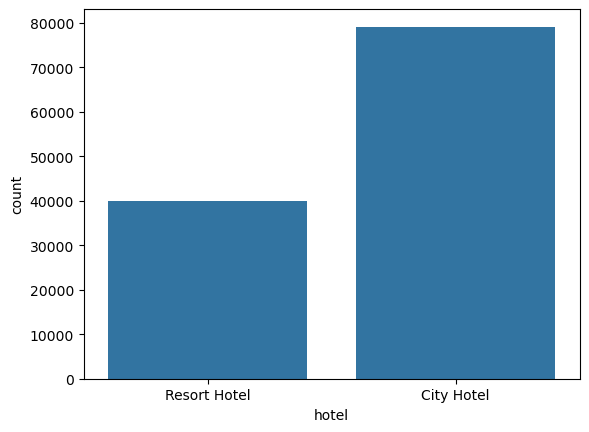

In [23]:
sns.countplot(data=df, x='hotel')
plt.show()

In [24]:
df['arrival_date_month'].value_counts()

arrival_date_month
August       13861
July         12644
May          11780
October      11147
April        11078
June         10929
September    10500
March         9768
February      8052
November      6771
December      6759
January       5921
Name: count, dtype: int64

In [25]:
df.groupby('arrival_date_month')['adr']\
  .mean()\
  .sort_values(ascending=False)

arrival_date_month
August       140.255303
July         126.944704
June         116.761489
May          108.771400
September    105.127290
April        100.468146
October       88.011401
December      81.321256
March         80.884282
November      73.966448
February      73.717054
January       70.451631
Name: adr, dtype: float64

In [35]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

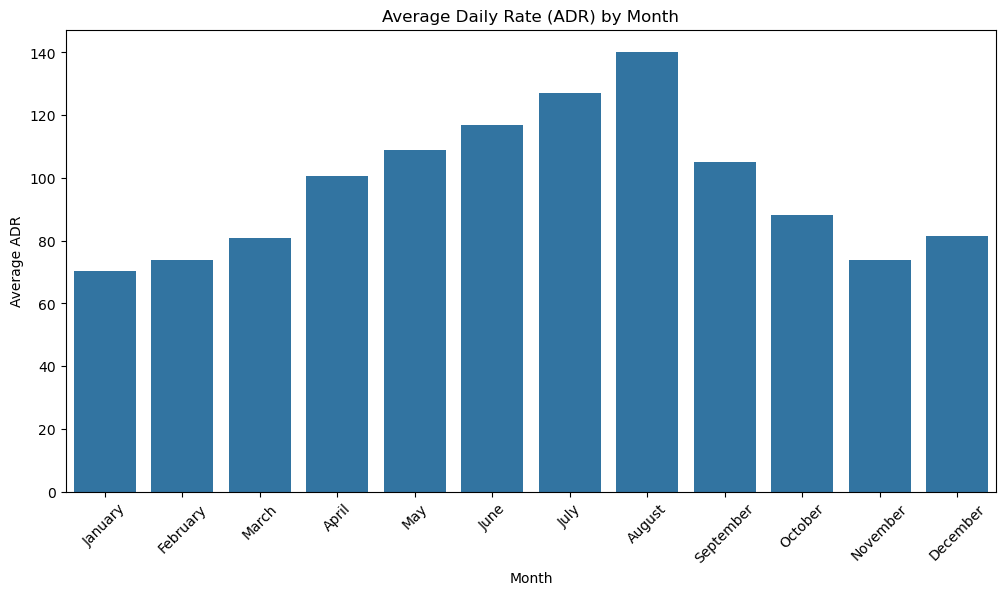

In [36]:
adr_month = (
    df.groupby('arrival_date_month')['adr']
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=adr_month.index,
    y=adr_month.values
)

plt.title("Average Daily Rate (ADR) by Month")
plt.xlabel("Month")
plt.ylabel("Average ADR")

plt.xticks(rotation=45)

plt.show()

#insights

Peak Season:
May → August

Off Season:
November → January

In [26]:
df.groupby('hotel')['adr'].mean()

hotel
City Hotel      105.503191
Resort Hotel     94.983054
Name: adr, dtype: float64

City Hotels exhibit a higher average ADR compared to Resort Hotels while also receiving significantly more bookings. This indicates stronger demand and pricing power for City Hotels, making hotel type an important feature for dynamic pricing decisions.

In [27]:
df.groupby('hotel')['is_canceled'].mean()*100

hotel
City Hotel      41.785935
Resort Hotel    27.767373
Name: is_canceled, dtype: float64

Observation

City Hotels experience significantly higher cancellation rates than Resort Hotels (41.8% vs 27.8%). Although City Hotels generate greater demand and ADR, a substantial proportion of bookings are cancelled, making cancellation behaviour an important factor in revenue optimization.


In [28]:
(
df.groupby('market_segment')['is_canceled']
.mean()
.sort_values(ascending=False)
*100
)

market_segment
Undefined        100.000000
Groups            61.108585
Online TA         36.758970
Offline TA/TO     34.331321
Aviation          22.127660
Corporate         18.761833
Direct            15.371165
Complementary     12.225275
Name: is_canceled, dtype: float64

#Observation

Group bookings exhibit the highest cancellation rate (61%), followed by Online Travel Agency bookings (37%). Direct and Corporate bookings demonstrate substantially lower cancellation rates, indicating more reliable revenue streams. Market segment is therefore expected to play a significant role in pricing and demand forecasting.

In [30]:
df.groupby(
    pd.cut(
        df['lead_time'],
        bins=[0,30,90,180,365,800]
    )
)['is_canceled'].mean()*100

/var/folders/8p/qkrsr0m519l8xcgstlgqn9c00000gn/T/ipykernel_52831/1807315155.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


lead_time
(0, 30]       20.890581
(30, 90]      37.729012
(90, 180]     44.735049
(180, 365]    55.456487
(365, 800]    67.651732
Name: is_canceled, dtype: float64

#Observation
Cancellation probability increases steadily with booking lead time. Customers booking more than one year in advance exhibit cancellation rates exceeding 67%, while bookings made within 30 days show only 21% cancellation. Lead time is therefore a critical predictor of booking reliability and future demand.

In [31]:
df['market_segment'].value_counts()

market_segment
Online TA        56408
Offline TA/TO    24182
Groups           19791
Direct           12582
Corporate         5282
Complementary      728
Aviation           235
Undefined            2
Name: count, dtype: int64

In [32]:
df.groupby('market_segment')['adr']\
  .mean()\
  .sort_values(ascending=False)

market_segment
Online TA        117.318022
Direct           115.634595
Aviation         100.994383
Offline TA/TO     87.479307
Groups            79.559620
Corporate         69.528332
Undefined         15.000000
Complementary      2.945838
Name: adr, dtype: float64

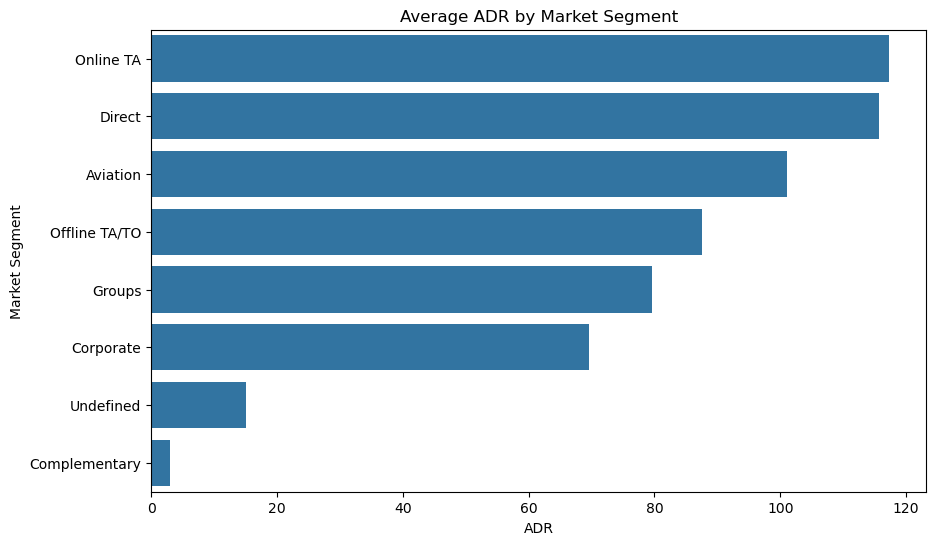

In [38]:
segment_adr = (
    df.groupby('market_segment')['adr']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=segment_adr.values,
    y=segment_adr.index
)

plt.title("Average ADR by Market Segment")
plt.xlabel("ADR")
plt.ylabel("Market Segment")

plt.show()

Direct bookings emerge as one of the most valuable customer segments. Despite contributing fewer bookings than Online Travel Agencies, Direct customers exhibit the second-highest ADR while maintaining one of the lowest cancellation rates. This suggests that encouraging direct bookings could improve revenue stability and profitability.

/var/folders/8p/qkrsr0m519l8xcgstlgqn9c00000gn/T/ipykernel_52831/1676221374.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


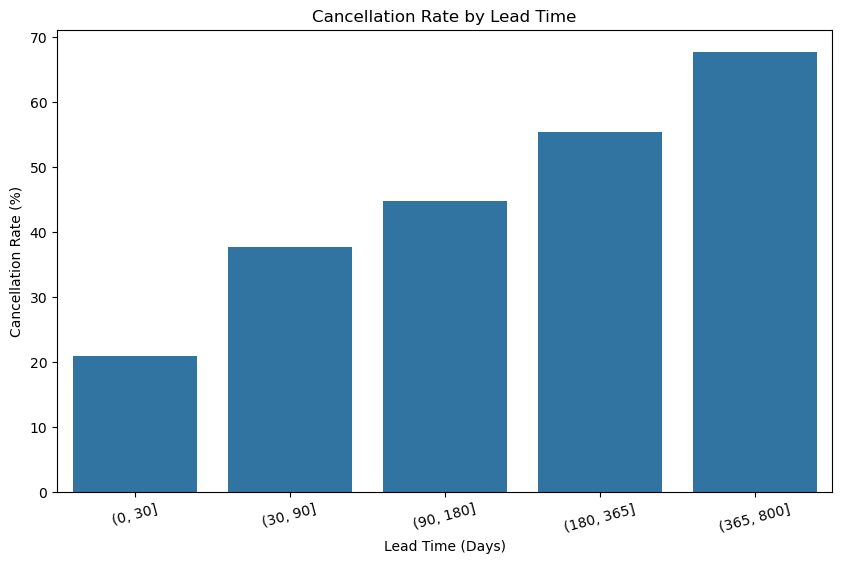

In [39]:
lead_cancel = (
    df.groupby(
        pd.cut(
            df['lead_time'],
            bins=[0,30,90,180,365,800]
        )
    )['is_canceled']
    .mean()
    * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=lead_cancel.index.astype(str),
    y=lead_cancel.values
)

plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=15)

plt.show()

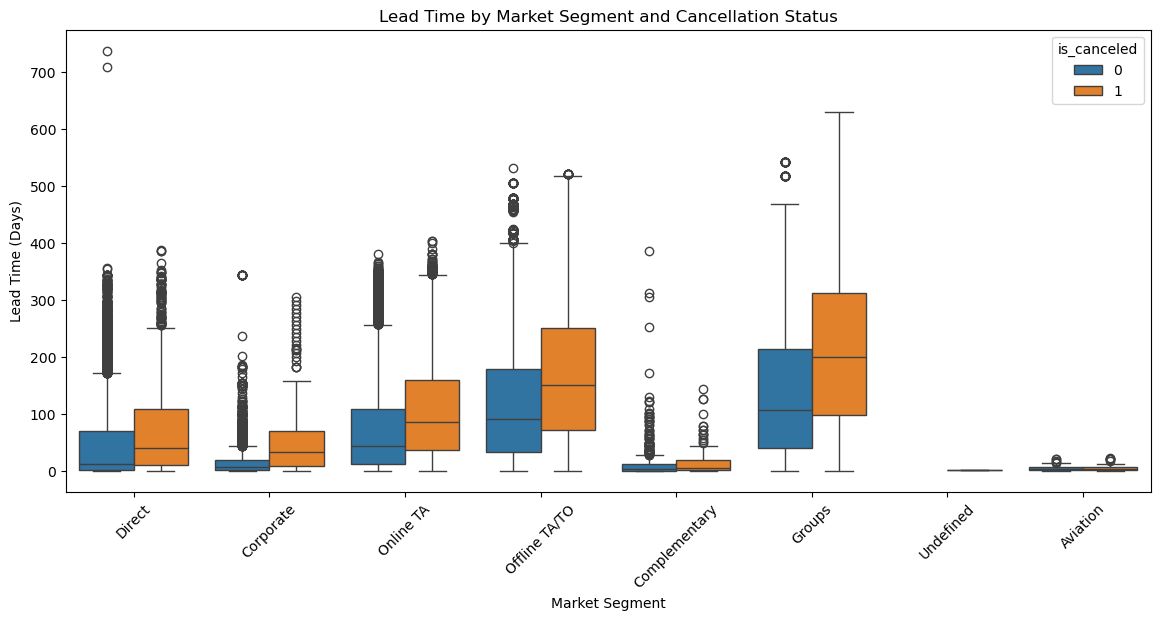

In [41]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='market_segment',
    y='lead_time',
    hue='is_canceled'
)

plt.title("Lead Time by Market Segment and Cancellation Status")
plt.xlabel("Market Segment")
plt.ylabel("Lead Time (Days)")

plt.xticks(rotation=45)

plt.show()

/var/folders/8p/qkrsr0m519l8xcgstlgqn9c00000gn/T/ipykernel_52831/2772924042.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


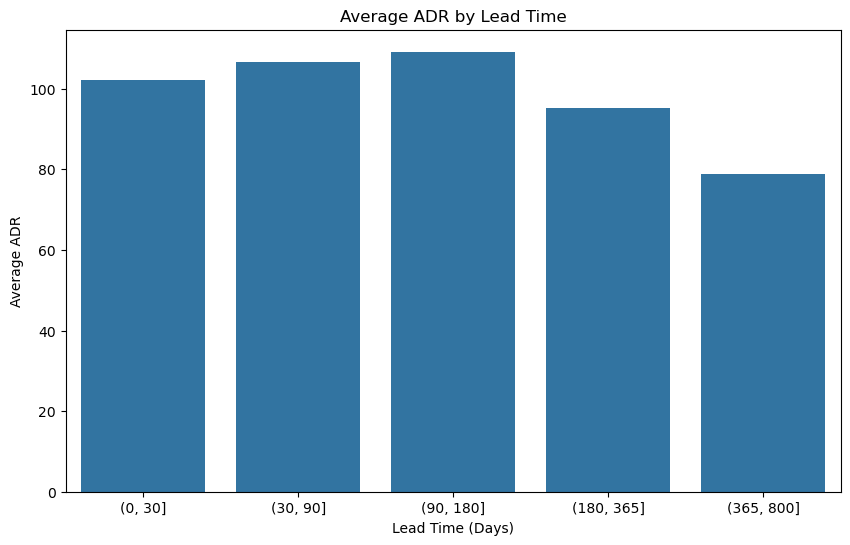

In [42]:
lead_price = (
    df.groupby(
        pd.cut(
            df['lead_time'],
            bins=[0,30,90,180,365,800]
        )
    )['adr']
    .mean()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=lead_price.index.astype(str),
    y=lead_price.values
)

plt.title("Average ADR by Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Average ADR")

plt.show()

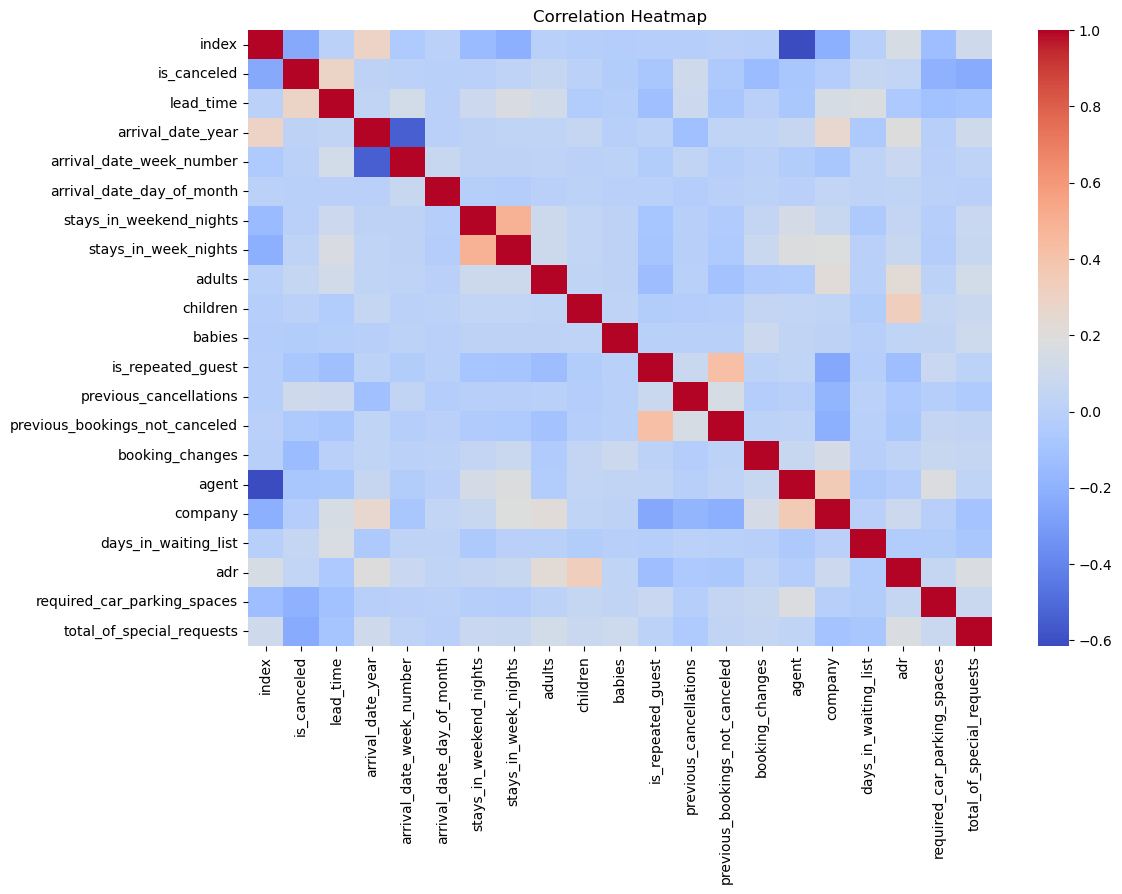

In [43]:
num_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    num_cols.corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

DATA CLEANING and Feature Engineering

In [44]:
df['adr'].describe()

count    119210.000000
mean        101.969092
std          50.434007
min          -6.380000
25%          69.500000
50%          94.950000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

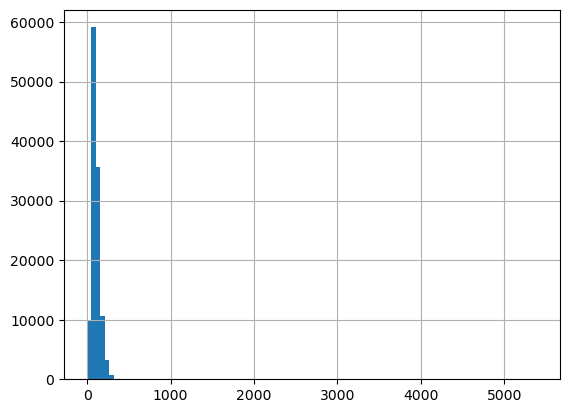

In [47]:
df['adr'].hist(bins=100)
plt.show()

In [48]:
(df['adr'] < 0).sum()

np.int64(1)

In [49]:
df['adr'].quantile([0.90, 0.95, 0.99, 0.999])

0.900    164.05500
0.950    193.50000
0.990    252.00000
0.999    326.26103
Name: adr, dtype: float64

In [50]:
df = df[df['adr'] >= 0]

df = df[df['adr'] <= df['adr'].quantile(0.999)]

In [51]:
features = [
    'hotel',
    'lead_time',
    'arrival_date_month',
    'market_segment',
    'distribution_channel',
    'customer_type',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'booking_changes',
    'adr'
]

df[features].isnull().sum()

hotel                     0
lead_time                 0
arrival_date_month        0
market_segment            0
distribution_channel      0
customer_type             0
adults                    0
children                  4
babies                    0
previous_cancellations    0
booking_changes           0
adr                       0
dtype: int64

In [52]:
df['children'] = df['children'].fillna(0)

Remove impossible bookings , booking only with children no adults

In [53]:
df = df[~(
    (df['adults']==0) &
    (df['children']==0) &
    (df['babies']==0)
)]

In [54]:
df['customer_type'].value_counts()

customer_type
Transient          89365
Transient-Party    25078
Contract            4072
Group                574
Name: count, dtype: int64

In [55]:
df.groupby('customer_type')['adr'].mean()

customer_type
Contract            87.635639
Group               83.913780
Transient          106.794691
Transient-Party     86.104915
Name: adr, dtype: float64

In [56]:
df.groupby('customer_type')['is_canceled'].mean()*100

customer_type
Contract           30.992141
Group              10.104530
Transient          40.797852
Transient-Party    25.456575
Name: is_canceled, dtype: float64

In [57]:
features = [
    'hotel',
    'lead_time',
    'arrival_date_month',
    'market_segment',
    'distribution_channel',
    'customer_type',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'booking_changes'
]

target = 'adr'

In [58]:
df[features].head()

,hotel,lead_time,arrival_date_month,market_segment,distribution_channel,customer_type,adults,children,babies,previous_cancellations,booking_changes
0,Resort Hotel,342,July,Direct,Direct,Transient,2,0.0,0,0,3
1,Resort Hotel,737,July,Direct,Direct,Transient,2,0.0,0,0,4
2,Resort Hotel,7,July,Direct,Direct,Transient,1,0.0,0,0,0
3,Resort Hotel,13,July,Corporate,Corporate,Transient,1,0.0,0,0,0
4,Resort Hotel,14,July,Online TA,TA/TO,Transient,2,0.0,0,0,0


In [59]:
df[features].dtypes

hotel                      object
lead_time                   int64
arrival_date_month         object
market_segment             object
distribution_channel       object
customer_type              object
adults                      int64
children                  float64
babies                      int64
previous_cancellations      int64
booking_changes             int64
dtype: object

In [60]:
X = df[features]
y = df['adr']

In [61]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [64]:
print(X.shape)
X.head()

(119089, 32)


,lead_time,adults,children,babies,previous_cancellations,booking_changes,hotel_Resort Hotel,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,...,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,2,0.0,0,0,3,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,737,2,0.0,0,0,4,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,7,1,0.0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,13,1,0.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,14,2,0.0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,1,0


In [63]:
bool_cols = X.select_dtypes(include='bool').columns

X[bool_cols] = X[bool_cols].astype(int)

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (95271, 32)
X_test : (23818, 32)
y_train: (95271,)
y_test : (23818,)


In [119]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [121]:
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [122]:
y_pred = rf.predict(X_test)

In [108]:
training_columns = X.columns

In [124]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 17.438849081947925
RMSE: 26.130593442016583
R²  : 0.6914161194296082


In [127]:
import joblib

joblib.dump(
    rf,
    "hotel_pricing_model.pkl"
)

['hotel_pricing_model.pkl']

In [128]:
import os

size_mb = os.path.getsize(
    "hotel_pricing_model.pkl"
)/(1024*1024)

print(round(size_mb,2),"MB")

61.54 MB


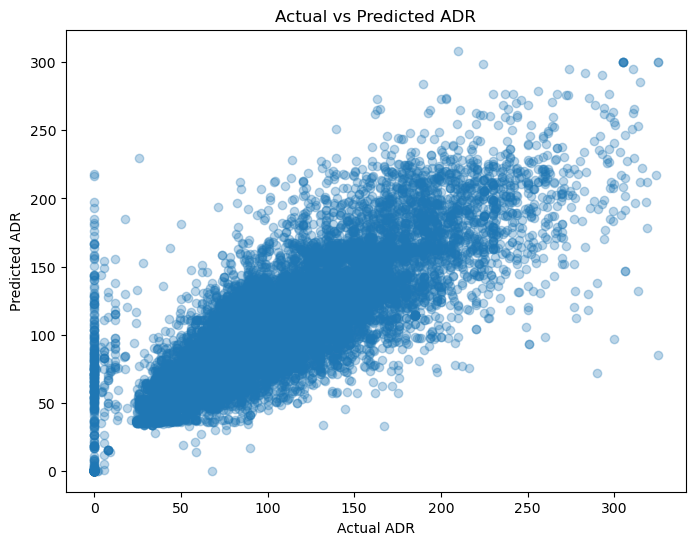

In [125]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual ADR")
plt.ylabel("Predicted ADR")
plt.title("Actual vs Predicted ADR")

plt.show()

In [126]:
(df['adr'] == 0).sum()

np.int64(1810)

In [74]:
df[df['adr']==0][
    ['hotel','market_segment','customer_type']
].head()

,hotel,market_segment,customer_type
0,Resort Hotel,Direct,Transient
1,Resort Hotel,Direct,Transient
125,Resort Hotel,Complementary,Transient
167,Resort Hotel,Online TA,Transient
168,Resort Hotel,Direct,Transient


In [75]:
df[df['adr']==0]['market_segment'].value_counts()

market_segment
Complementary    665
Online TA        319
Offline TA/TO    297
Groups           233
Direct           221
Corporate         71
Aviation           4
Name: count, dtype: int64

In [76]:
df[df['adr']==0]['customer_type'].value_counts()

customer_type
Transient          1340
Transient-Party     419
Group                31
Contract             20
Name: count, dtype: int64

In [77]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,lead_time,0.206100
2,children,0.127640
6,hotel_Resort Hotel,0.124754
1,adults,0.101775
7,arrival_date_month_August,0.085225
23,market_segment_Online TA,0.067478
11,arrival_date_month_July,0.048794
12,arrival_date_month_June,0.029378
5,booking_changes,0.026502
20,market_segment_Direct,0.025302


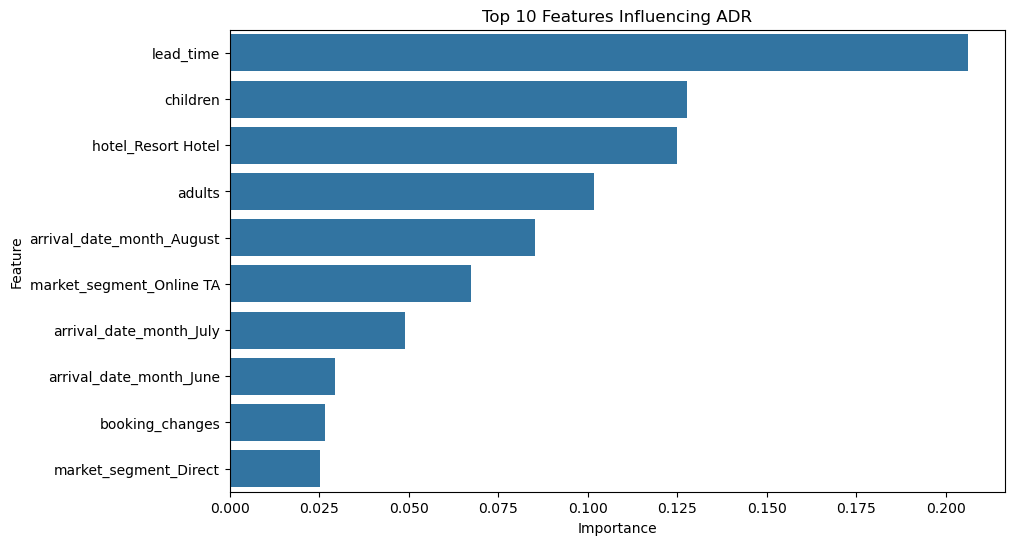

In [78]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features Influencing ADR")
plt.show()

Dynamic Pricing

In [81]:
month_score = {
    'July': 1,
    'August': 1,
    'May': 1,

    'March': 0.5,
    'April': 0.5,
    'June': 0.5,
    'September': 0.5,
    'October': 0.5,

    'January': 0,
    'February': 0,
    'November': 0,
    'December': 0
}

In [82]:
hotel_score = {
    'City Hotel': 1,
    'Resort Hotel': 0.7
}

In [83]:
platform_score = {
    'Online TA': 1,
    'Direct': 0.8,
    'Aviation': 0.6,
    'Offline TA/TO': 0.4,
    'Groups': 0.2
}

In [84]:
def lead_time_score(lead_time):

    if lead_time > 180:
        return 1

    elif lead_time > 90:
        return 0.6

    elif lead_time > 30:
        return 0.3

    return 0

In [85]:
def calculate_demand_score(
    month,
    hotel,
    market_segment
):

    score = (
        0.6 * month_score[month]
        + 0.2 * hotel_score[hotel]
        + 0.2 * platform_score.get(market_segment, 0)
    )

    return score * 100

In [88]:
#test
calculate_demand_score(
    month='August',
    hotel='City Hotel',
    market_segment='Online TA'
)

100.0

In [91]:
def calculate_risk_score(
    lead_time,
    market_segment
):

    group_score = 1 if market_segment == 'Groups' else 0

    online_ta_score = (
        1 if market_segment == 'Online TA'
        else 0
    )

    score = (
        0.6 * lead_time_score(lead_time)
        + 0.2 * group_score
        + 0.2 * online_ta_score
    )

    return score * 100

In [94]:
#test
calculate_risk_score(
    lead_time=250,
    market_segment='Groups'
)

80.0

In [95]:
def calculate_adjustment(
    demand_score,
    risk_score
):

    adjustment = (
        0.5 *
        (
            (2/3) * (demand_score/100)
            -
            (1/3) * (risk_score/100)
        )
    ) * 100

    return adjustment

In [100]:
#test
calculate_adjustment(
    demand_score=100,
    risk_score=0
)

33.33333333333333

In [99]:
#test
calculate_adjustment(
    demand_score=18,
    risk_score=80
)

-7.333333333333333

recommended ADR

In [101]:
def recommend_adr(
    predicted_adr,
    demand_score,
    risk_score
):

    adjustment_pct = calculate_adjustment(
        demand_score,
        risk_score
    )

    recommended_adr = (
        predicted_adr *
        (1 + adjustment_pct/100)
    )

    return round(recommended_adr, 2)

In [103]:
#test
recommend_adr(
    predicted_adr=100,
    demand_score=100,
    risk_score=0
)

133.33

In [104]:
df.sample(
    5,
    random_state=42
)[
    [
        'hotel',
        'arrival_date_month',
        'market_segment',
        'lead_time',
        'adr'
    ]
]

,hotel,arrival_date_month,market_segment,lead_time,adr
1592,Resort Hotel,September,Direct,54,98.00
29052,Resort Hotel,October,Groups,159,60.00
63760,City Hotel,February,Groups,32,75.00
93231,City Hotel,July,Offline TA/TO,95,79.56
78100,City Hotel,October,Online TA,16,123.33


In [105]:
def evaluate_booking(
    month,
    hotel,
    market_segment,
    lead_time,
    predicted_adr
):

    demand = calculate_demand_score(
        month,
        hotel,
        market_segment
    )

    risk = calculate_risk_score(
        lead_time,
        market_segment
    )

    adjustment = calculate_adjustment(
        demand,
        risk
    )

    recommended = recommend_adr(
        predicted_adr,
        demand,
        risk
    )

    return {
        "Demand Score": round(demand,2),
        "Risk Score": round(risk,2),
        "Adjustment %": round(adjustment,2),
        "Recommended ADR": round(recommended,2)
    }

In [107]:
#test
evaluate_booking(
    month='October',
    hotel='City Hotel',
    market_segment='Online TA',
    lead_time=16,
    predicted_adr=123.33
)

{'Demand Score': 70.0,
 'Risk Score': 20.0,
 'Adjustment %': 20.0,
 'Recommended ADR': 148.0}

In [109]:
booking = {
    "hotel": "City Hotel",
    "lead_time": 16,
    "arrival_date_month": "October",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    "customer_type": "Transient",
    "adults": 2,
    "children": 0,
    "babies": 0,
    "previous_cancellations": 0,
    "booking_changes": 0
}

In [110]:
booking_df = pd.DataFrame([booking])

booking_df

,hotel,lead_time,arrival_date_month,market_segment,distribution_channel,customer_type,adults,children,babies,previous_cancellations,booking_changes
0,City Hotel,16,October,Online TA,TA/TO,Transient,2,0,0,0,0


In [111]:
booking_encoded = pd.get_dummies(
    booking_df,
    drop_first=True
)

In [112]:
booking_encoded = booking_encoded.reindex(
    columns=training_columns,
    fill_value=0
)

In [113]:
predicted_adr = rf.predict(
    booking_encoded
)[0]

print(predicted_adr)


87.73


In [115]:
predicted_adr = rf.predict(
    booking_encoded
)[0]

print(round(predicted_adr,2))

87.73


In [116]:
def predict_and_recommend(booking):

    booking_df = pd.DataFrame([booking])

    booking_encoded = pd.get_dummies(
        booking_df,
        drop_first=True
    )

    booking_encoded = booking_encoded.reindex(
        columns=training_columns,
        fill_value=0
    )

    predicted_adr = rf.predict(
        booking_encoded
    )[0]

    demand_score = calculate_demand_score(
        booking['arrival_date_month'],
        booking['hotel'],
        booking['market_segment']
    )

    risk_score = calculate_risk_score(
        booking['lead_time'],
        booking['market_segment']
    )

    adjustment = calculate_adjustment(
        demand_score,
        risk_score
    )

    recommended_adr = recommend_adr(
        predicted_adr,
        demand_score,
        risk_score
    )

    return {
        "Predicted ADR": round(predicted_adr,2),
        "Demand Score": round(demand_score,2),
        "Risk Score": round(risk_score,2),
        "Adjustment %": round(adjustment,2),
        "Recommended ADR": round(recommended_adr,2)
    }

In [117]:
booking = {
    "hotel": "City Hotel",
    "lead_time": 16,
    "arrival_date_month": "October",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    "customer_type": "Transient",
    "adults": 2,
    "children": 0,
    "babies": 0,
    "previous_cancellations": 0,
    "booking_changes": 0
}

predict_and_recommend(booking)

{'Predicted ADR': np.float64(87.73),
 'Demand Score': 70.0,
 'Risk Score': 20.0,
 'Adjustment %': 20.0,
 'Recommended ADR': np.float64(105.28)}

In [118]:
import joblib

joblib.dump(rf, "hotel_pricing_model.pkl")
joblib.dump(training_columns, "training_columns.pkl")

['training_columns.pkl']